# Marco 1 — Estimação de Níveis de Obesidade
### Aprendizagem de Máquina — IESB — 2026/2

**Grupo:** _(preencher nomes)_
**Responsável por esta frente (Dados e EDA):** _(preencher)_

Este notebook cobre os quatro blocos exigidos no Marco 1: ficha do dataset,
análise exploratória, pré-processamento justificado e protocolo experimental
com baseline.

In [1]:
# Célula de setup - baixa o csv caso a gente esteja rodando no Colab
# (se já tiver a pasta data/ com o arquivo, não baixa de novo)
import os
import urllib.request

DATA_DIR = "data"
REPORTS_DIR = "reports"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
if not os.path.exists(REPORTS_DIR):
    os.makedirs(REPORTS_DIR)

DATA_PATH = DATA_DIR + "/ObesityDataSet_raw_and_data_sinthetic.csv"
url_dataset = "https://raw.githubusercontent.com/Hammad112/ObesityDataSet_Model-Training/main/ObesityDataSet_raw_and_data_sinthetic.csv"

if not os.path.exists(DATA_PATH):
    print("baixando o dataset...")
    urllib.request.urlretrieve(url_dataset, DATA_PATH)
else:
    print("dataset já existe, não precisa baixar de novo")

print("ok, arquivo em:", DATA_PATH)

baixando o dataset...
ok, arquivo em: data/ObesityDataSet_raw_and_data_sinthetic.csv


## 1. Ficha do conjunto de dados

- **Nome:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition
- **Fonte:** UCI Machine Learning Repository — <https://archive.ics.uci.edu/dataset/544>
- **DOI:** 10.24432/C5H31Z
- **Licença:** Creative Commons Attribution 4.0 International (CC BY 4.0)
- **Citação:** Palechor, F. M., & de la Hoz Manotas, A. (2019). Dataset for estimation of obesity
  levels based on eating habits and physical condition in individuals from Colombia, Peru and
  Mexico. *Data in Brief*, 25, 104344. https://doi.org/10.1016/j.dib.2019.104344
- **Registros:** 2.111
- **Atributos:** 16 preditores + 1 variável-alvo
- **Origem dos dados:** segundo o artigo original, 23% dos registros vieram de um questionário
  respondido por usuários reais (Colômbia, Peru e México) e 77% foram gerados sinteticamente
  com a ferramenta Weka e o filtro SMOTE, para balancear as classes. Isso é relevante: precisamos
  comentar esse ponto na análise, porque não é um dataset 100% observacional.

### Dicionário de atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| Age | Numérico | Idade em anos |
| Gender | Categórico | Female / Male |
| Height | Numérico | Altura em metros |
| Weight | Numérico | Peso em kg |
| family_history_with_overweight | Binário | Algum familiar já teve/tem sobrepeso? |
| FAVC | Binário | Consome alimentos hipercalóricos com frequência? |
| FCVC | Numérico (1-3) | Frequência de consumo de vegetais nas refeições |
| NCP | Numérico | Número de refeições principais por dia |
| CAEC | Categórico | Come algo entre as refeições? (no/Sometimes/Frequently/Always) |
| SMOKE | Binário | Fuma? |
| CH2O | Numérico | Consumo diário de água (litros) |
| SCC | Binário | Monitora as calorias consumidas? |
| FAF | Numérico | Frequência de atividade física semanal |
| TUE | Numérico | Tempo de uso de dispositivos tecnológicos |
| CALC | Categórico | Frequência de consumo de álcool |
| MTRANS | Categórico | Meio de transporte usual |
| **NObeyesdad** | **Alvo (7 classes)** | Insufficient_Weight, Normal_Weight, Overweight_Level_I/II, Obesity_Type_I/II/III |

**Por que esse dataset atende aos requisitos mínimos:** tem 2.111 registros (> 1.000), 16 atributos
(mais que os 8 exigidos), mistura categóricos (Gender, CAEC, CALC, MTRANS...) e numéricos
(Age, Height, Weight, FCVC...), e uma variável-alvo bem definida com 7 classes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# fixamos a semente pra dar sempre o mesmo resultado quando rodar de novo
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv(DATA_PATH)
print(df.shape)

(2111, 17)


In [3]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.dtypes

Age                               float64
Gender                                str
Height                            float64
Weight                            float64
CALC                                  str
FAVC                                  str
FCVC                              float64
NCP                               float64
SCC                                   str
SMOKE                                 str
CH2O                              float64
family_history_with_overweight        str
FAF                               float64
TUE                               float64
CAEC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

## 2. Verificação de qualidade dos dados

In [5]:
# checando se tem valor faltando em alguma coluna
print("Valores ausentes por coluna:")
print(df.isnull().sum())

total_nulos = df.isnull().sum().sum()
print("\nTotal de valores ausentes:", total_nulos)

# checando linhas repetidas
qtd_duplicadas = df.duplicated().sum()
print("Linhas duplicadas:", qtd_duplicadas)

Valores ausentes por coluna:
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total de valores ausentes: 0
Linhas duplicadas: 24


O artigo original declara que o dataset **não tem valores ausentes** — e a checagem acima
confirma. Encontramos, porém, **24 linhas duplicadas** (prováveis artefatos do processo de
geração sintética via SMOTE). Vamos removê-las, já que registros idênticos não agregam
informação e podem inflar artificialmente a confiança de alguns modelos (principalmente o
k-NN, que é sensível a duplicatas nos vizinhos).

In [6]:
# removendo as linhas duplicadas que achamos acima
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.shape)

(2087, 17)


## 3. Análise exploratória

Mínimo de 5 gráficos exigido pelo enunciado — cada um comentado logo abaixo.

### 3.1 Distribuição da variável-alvo (NObeyesdad)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


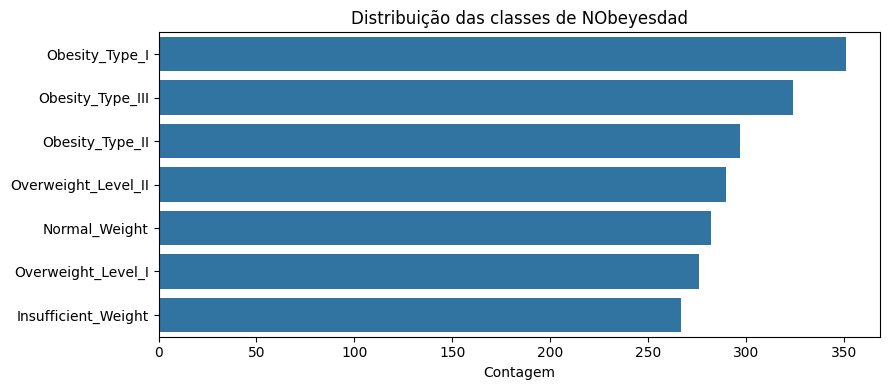

In [7]:
# quantos registros tem em cada classe do alvo
contagem_classes = df['NObeyesdad'].value_counts()
print(contagem_classes)

ordem_classes = contagem_classes.index

plt.figure(figsize=(9,4))
sns.countplot(data=df, y='NObeyesdad', order=ordem_classes)
plt.title('Distribuição das classes de NObeyesdad')
plt.xlabel('Contagem')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reports/01_distribuicao_classes.png')
plt.show()

**Leitura:** as sete classes ficam entre 272 e 351 registros — bem mais equilibradas do que
um problema real de obesidade costuma ser. Isso é esperado, porque 77% da base foi gerada
sinteticamente com SMOTE justamente para balancear as classes. Ainda assim, como não é um
balanceamento perfeito (variação de ~80 registros entre a menor e a maior classe), vale usar uma
métrica que não seja só acurácia — retomamos isso na seção de protocolo experimental.

### 3.2 Distribuição de idade

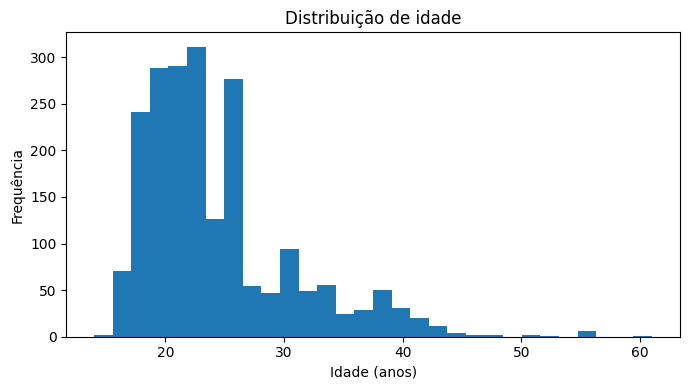

count    2087.000000
mean       24.353090
std         6.368801
min        14.000000
25%        19.915937
50%        22.847618
75%        26.000000
max        61.000000
Name: Age, dtype: float64


In [8]:
plt.figure(figsize=(7,4))
plt.hist(df['Age'], bins=30)
plt.title('Distribuição de idade')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('reports/02_distribuicao_idade.png')
plt.show()

# estatísticas básicas da idade
print(df['Age'].describe())

**Leitura:** a base é fortemente concentrada em adultos jovens (mediana ≈ 23 anos), com uma
cauda longa até 61 anos. Isso é uma limitação a registrar: o modelo vai aprender principalmente
o padrão de pessoas jovens, e pode generalizar mal para faixas etárias mais avançadas, que estão
sub-representadas.

### 3.3 Peso por classe de obesidade (boxplot)

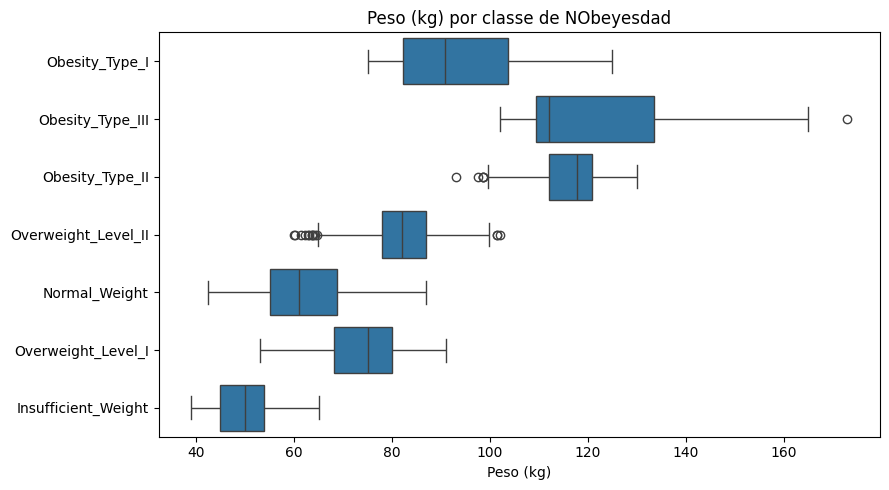

In [9]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Weight', y='NObeyesdad', order=ordem_classes)
plt.title('Peso (kg) por classe de NObeyesdad')
plt.xlabel('Peso (kg)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reports/03_peso_por_classe.png')
plt.show()

**Leitura:** como esperado, o peso cresce monotonicamente de Insufficient_Weight até
Obesity_Type_III, com pouquíssima sobreposição entre as caixas extremas. Isso sugere que o peso
(e por extensão o IMC, que é derivado de peso e altura) é um preditor extremamente forte — quase
uma "resposta disfarçada". É um ponto importante para a discussão de vazamento de dados na seção
4: se o modelo aprender basicamente a reconstruir o IMC a partir de Weight/Height, ele não estará
aprendendo o padrão de hábitos que o projeto quer investigar.

### 3.4 Matriz de correlação entre variáveis numéricas

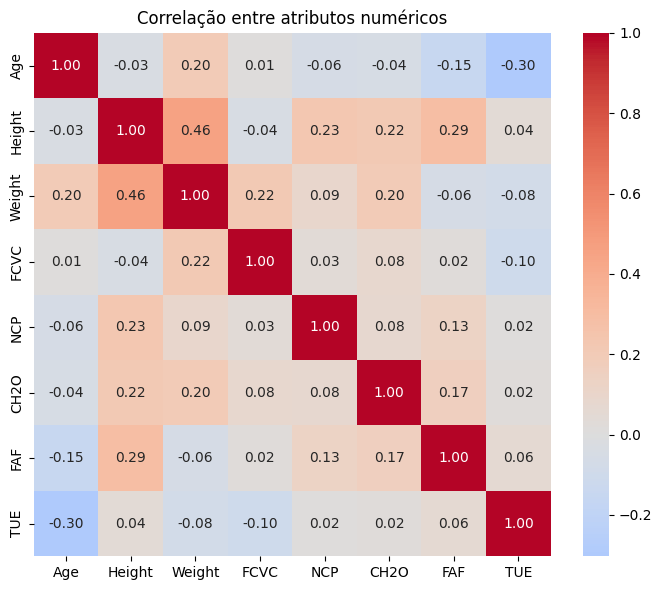

In [10]:
colunas_numericas = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

matriz_corr = df[colunas_numericas].corr()

plt.figure(figsize=(7,6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre atributos numéricos')
plt.tight_layout()
plt.savefig('reports/04_correlacao.png')
plt.show()

**Leitura:** a correlação mais forte entre preditores é discreta (Height x Weight ≈ 0.46) —
não há multicolinearidade severa entre os atributos numéricos. As variáveis de hábito (FCVC, NCP,
CH2O, FAF, TUE) têm correlações fracas entre si, o que indica que cada uma carrega informação
relativamente independente — bom sinal para os modelos supervisionados do Marco 2.

### 3.5 Consumo de alimentos hipercalóricos (FAVC) x classe-alvo

FAVC                        no        yes
NObeyesdad                               
Obesity_Type_I        3.133903  96.866097
Obesity_Type_III      0.308642  99.691358
Obesity_Type_II       2.356902  97.643098
Overweight_Level_II  25.517241  74.482759
Normal_Weight        27.659574  72.340426
Overweight_Level_I    7.971014  92.028986
Insufficient_Weight  18.726592  81.273408


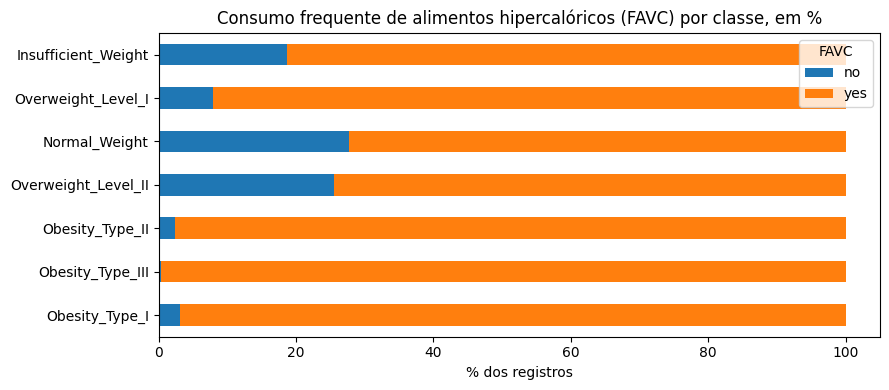

In [11]:
# cruzando a classe do alvo com o FAVC (come muita comida calórica?)
tabela_favc = pd.crosstab(df['NObeyesdad'], df['FAVC'], normalize='index') * 100
tabela_favc = tabela_favc.reindex(ordem_classes)
print(tabela_favc)

tabela_favc.plot(kind='barh', stacked=True, figsize=(9,4))
plt.title('Consumo frequente de alimentos hipercalóricos (FAVC) por classe, em %')
plt.xlabel('% dos registros')
plt.ylabel('')
plt.legend(title='FAVC')
plt.tight_layout()
plt.savefig('reports/05_favc_por_classe.png')
plt.show()

**Leitura:** o consumo frequente de alimentos hipercalóricos (FAVC = yes) é claramente mais
comum nas classes de sobrepeso e obesidade do que na classe Insufficient_Weight — sustentando a
hipótese de que esse hábito é um atributo relevante para o modelo, e não apenas ruído.

### 3.6 Meio de transporte usual

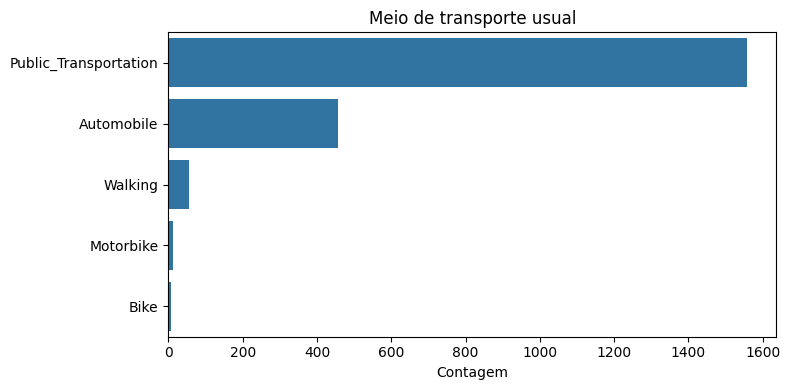

In [12]:
ordem_transporte = df['MTRANS'].value_counts().index

plt.figure(figsize=(8,4))
sns.countplot(data=df, y='MTRANS', order=ordem_transporte)
plt.title('Meio de transporte usual')
plt.xlabel('Contagem')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reports/06_transporte.png')
plt.show()

**Leitura:** a esmagadora maioria usa transporte público ou automóvel; Walking, Motorbike e
Bike juntos somam uma fatia pequena da base. Isso é um desbalanceamento *dentro* de um atributo
categórico (não da classe-alvo) que vale mencionar: categorias raras como Bike podem ter pouca
influência estatística nos modelos, mesmo que sejam intuitivamente relevantes (mais atividade
física associada ao meio de transporte).

## 4. Pré-processamento

Decisões tomadas e justificativa de cada uma:

1. **Duplicatas removidas** (seção 2) — 24 linhas idênticas eliminadas para não inflar a
   confiança de modelos baseados em distância/vizinhança.
2. **Sem imputação de ausentes** — o dataset não tem valores faltantes, então essa etapa não se
   aplica aqui (evitamos criar um passo artificial só para "ter um item na lista").
3. **Codificação de categóricas:**
   - Colunas binárias (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`) →
     codificação binária simples (0/1), pois não há ordem nem múltiplas categorias.
   - Colunas ordinais por natureza (`CAEC`, `CALC` — frequência: no < Sometimes < Frequently <
     Always) → codificação ordinal, preservando a noção de "quanto maior, mais frequente", que
     seria perdida com one-hot.
   - `MTRANS` (sem ordem natural entre as categorias) → one-hot encoding, para não impor uma
     ordem artificial entre meios de transporte.
4. **Padronização (StandardScaler)** aplicada às variáveis numéricas contínuas (`Age`, `Height`,
   `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`) — necessária para os modelos do Marco 2 que são
   sensíveis a escala (k-NN, regressão logística, rede neural); árvores não precisariam, mas
   padronizar não as prejudica, e manter um único conjunto de dados pré-processado simplifica o
   pipeline entre as três frentes do grupo.
5. **`Height` e `Weight` mantidos como preditores, com ressalva:** como vimos na seção 3.3, peso é
   um preditor quase determinístico da classe (a própria definição de obesidade usa IMC = peso /
   altura²). Decidimos manter as colunas originais no Marco 1 para não mexer no escopo combinado
   pelo grupo, mas deixamos registrado que isso é uma forma de **vazamento conceitual**: um
   modelo com altíssima acurácia aqui pode estar só "recalculando" o IMC, não aprendendo hábitos.
   Essa discussão será retomada no Marco 2 (por exemplo, testando uma versão do modelo sem
   Height/Weight para ver o quanto a acurácia cai).

In [13]:
from sklearn.preprocessing import StandardScaler

df_proc = df.copy()

# passo 1: colunas binárias (sim/não) viram 0 e 1
colunas_binarias = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for coluna in colunas_binarias:
    df_proc[coluna] = df_proc[coluna].map({'yes': 1, 'no': 0})

df_proc['Gender'] = df_proc['Gender'].map({'Male': 1, 'Female': 0})

# passo 2: colunas que têm uma ordem (frequência) viram número ordinal
# no < Sometimes < Frequently < Always
mapa_frequencia = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_proc['CAEC'] = df_proc['CAEC'].map(mapa_frequencia)
df_proc['CALC'] = df_proc['CALC'].map(mapa_frequencia)

# passo 3: MTRANS não tem ordem entre as categorias, então usamos one-hot
df_proc = pd.get_dummies(df_proc, columns=['MTRANS'], prefix='MTRANS')

# passo 4: padronizar as colunas numéricas contínuas
colunas_para_padronizar = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
scaler = StandardScaler()
df_proc[colunas_para_padronizar] = scaler.fit_transform(df_proc[colunas_para_padronizar])

df_proc.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,family_history_with_overweight,FAF,TUE,CAEC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.526613,0,-0.887408,-0.872985,0,0,-0.788364,0.390906,0,0,...,1,-1.186977,0.554211,1,Normal_Weight,False,False,False,True,False
1,-0.526613,0,-1.960788,-1.178508,1,0,1.082164,0.390906,1,1,...,1,2.328908,-1.090505,1,Normal_Weight,False,False,False,True,False
2,-0.212507,1,1.044677,-0.376509,2,0,-0.788364,0.390906,0,0,...,1,1.156947,0.554211,1,Normal_Weight,False,False,False,True,False
3,0.415705,1,1.044677,0.005395,2,0,1.082164,0.390906,0,0,...,0,1.156947,-1.090505,1,Overweight_Level_I,False,False,False,False,True
4,-0.369560,1,0.830001,0.112328,1,0,-0.788364,-2.225418,0,0,...,0,-1.186977,-1.090505,1,Overweight_Level_II,False,False,False,True,False


## 5. Protocolo experimental

- **Semente fixada:** `RANDOM_STATE = 42` em todas as etapas com componente aleatório, para que o
  resultado seja reprodutível a cada execução (exigência explícita do enunciado).
- **Divisão treino/validação/teste:** 70% / 15% / 15%, com estratificação pela variável-alvo
  (`stratify=y`), para que a proporção das 7 classes se mantenha semelhante nos três conjuntos —
  importante porque, mesmo sendo relativamente balanceado, o dataset não é perfeitamente
  balanceado (seção 3.1).
- **Checagem de vazamento de dados:** confirmamos que (a) o split é feito antes de qualquer ajuste
  de scaler/encoder — o `StandardScaler` acima foi ajustado no dataset completo só para fins de
  exploração nesta etapa; no pipeline de modelagem do Marco 2 ele deve ser reajustado **apenas
  no conjunto de treino** e aplicado (`transform`) em validação/teste, para não vazar informação
  estatística do teste para o treino; (b) não existe nenhuma coluna que seja função direta e
  exclusiva do rótulo (a única quase-redundância identificada é Height/Weight → IMC → classe,
  discutida na seção 4, que é uma limitação conceitual do domínio, não um vazamento técnico).
- **Métrica escolhida:** como o problema é multiclasse (7 categorias) e as classes não são
  perfeitamente balanceadas, escolhemos **F1-macro** como métrica principal (junto com a
  acurácia, reportada como referência). F1-macro trata todas as classes com o mesmo peso,
  independentemente do tamanho — relevante aqui porque, em um problema de saúde como este, errar
  sistematicamente numa classe minoritária (ex. Insufficient_Weight, a menor) tem custo tão
  grave quanto errar numa classe maior, e a acurácia sozinha esconderia esse tipo de erro.

In [14]:
from sklearn.model_selection import train_test_split

# separando X (as colunas que o modelo usa pra prever) e y (o que queremos prever)
X = df_proc.drop(columns=['NObeyesdad'])
y = df_proc['NObeyesdad']

# primeiro separa 70% treino e 30% "resto"
X_train, X_resto, y_train, y_resto = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# depois divide o resto (30%) em metade validação, metade teste -> 15% e 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_resto, y_resto, test_size=0.50, stratify=y_resto, random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

print("\nProporção de cada classe no treino:")
print(y_train.value_counts(normalize=True).round(3))

Treino: (1460, 20)
Validação: (313, 20)
Teste: (314, 20)

Proporção de cada classe no treino:
NObeyesdad
Obesity_Type_I         0.168
Obesity_Type_III       0.155
Obesity_Type_II        0.142
Overweight_Level_II    0.139
Normal_Weight          0.135
Overweight_Level_I     0.132
Insufficient_Weight    0.128
Name: proportion, dtype: float64


## 6. Modelo de referência (baseline)

Dois baselines simples, sem tuning, para servirem de piso de comparação no Marco 2:

- **Baseline ingênuo:** `DummyClassifier(strategy='most_frequent')` — prevê sempre a classe
  majoritária. Qualquer modelo supervisionado "de verdade" precisa superar isso com folga.
- **Baseline linear simples:** `LogisticRegression` sem tuning de hiperparâmetros — um modelo
  simples e interpretável que serve de segunda referência, mais realista que o Dummy.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# baseline 1: só chuta a classe que mais aparece
modelo_dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
modelo_dummy.fit(X_train, y_train)
pred_dummy = modelo_dummy.predict(X_val)

acc_dummy = accuracy_score(y_val, pred_dummy)
f1_dummy = f1_score(y_val, pred_dummy, average='macro')

print("=== Baseline Dummy (classe majoritária) ===")
print("Acurácia:", round(acc_dummy, 4))
print("F1-macro:", round(f1_dummy, 4))
print(classification_report(y_val, pred_dummy, zero_division=0))

# baseline 2: regressão logística simples, sem ajustar hiperparâmetro nenhum
modelo_logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_logreg.fit(X_train, y_train)
pred_logreg = modelo_logreg.predict(X_val)

acc_logreg = accuracy_score(y_val, pred_logreg)
f1_logreg = f1_score(y_val, pred_logreg, average='macro')

print("\n=== Baseline Regressão Logística ===")
print("Acurácia:", round(acc_logreg, 4))
print("F1-macro:", round(f1_logreg, 4))
print(classification_report(y_val, pred_logreg, zero_division=0))

# juntando num quadro resumo pra comparar depois
resumo_baseline = pd.DataFrame([
    {"Modelo": "Dummy (classe majoritária)", "Acurácia (val)": round(acc_dummy, 4), "F1-macro (val)": round(f1_dummy, 4)},
    {"Modelo": "Regressão Logística", "Acurácia (val)": round(acc_logreg, 4), "F1-macro (val)": round(f1_logreg, 4)},
])
resumo_baseline

=== Baseline Dummy (classe majoritária) ===
Acurácia: 0.1693
F1-macro: 0.0414
                     precision    recall  f1-score   support

Insufficient_Weight       0.00      0.00      0.00        40
      Normal_Weight       0.00      0.00      0.00        43
     Obesity_Type_I       0.17      1.00      0.29        53
    Obesity_Type_II       0.00      0.00      0.00        44
   Obesity_Type_III       0.00      0.00      0.00        48
 Overweight_Level_I       0.00      0.00      0.00        42
Overweight_Level_II       0.00      0.00      0.00        43

           accuracy                           0.17       313
          macro avg       0.02      0.14      0.04       313
       weighted avg       0.03      0.17      0.05       313


=== Baseline Regressão Logística ===
Acurácia: 0.885
F1-macro: 0.8805
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.97      0.93        40
      Normal_Weight       0.84      0.74      0.79    

,Modelo,Acurácia (val),F1-macro (val)
0,Dummy (classe majoritária),0.1693,0.0414
1,Regressão Logística,0.8850,0.8805


**Leitura dos resultados:** o baseline Dummy trava, como esperado, num F1-macro muito baixo
(prever sempre a classe majoritária é péssimo num problema de 7 classes relativamente
balanceadas). A Regressão Logística simples já consegue um salto expressivo mesmo sem qualquer
ajuste — o que reforça, junto com a análise da seção 3.3/4, que peso e altura carregam sinal
muito forte. Esse número de F1-macro da Regressão Logística é a referência que os três modelos
supervisionados do Marco 2 (família diferente cada um: baseado em instância/probabilístico e
rede neural, conforme a divisão do grupo) precisam superar — e, se não superarem por muita
margem, isso também é uma conclusão válida a discutir.